In [1]:
%pip install xgboost

KeyboardInterrupt: 

In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from xgboost import XGBRegressor, XGBClassifier

from sklearn.metrics import (
    r2_score, mean_absolute_error, mean_squared_error,
    accuracy_score, precision_score, recall_score
)

import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df=pd.read_csv('fsw_clean_dataset.csv')

In [4]:
X = df[['D','V','N','HeatInput']]
y = df['Yield']

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [6]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [7]:
xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    random_state=42
)

xgb_model.fit(X_train_scaled, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)

In [8]:
y_pred = xgb_model.predict(X_test_scaled)

In [9]:
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("R2 Score:", r2)
print("MAE:", mae)
print("RMSE:", rmse)

R2 Score: 0.919816319377104
MAE: 3.035456431995736
RMSE: 6.917100147117233


In [10]:
threshold = 430

y_train_class = (y_train > threshold).astype(int)
y_test_class = (y_test > threshold).astype(int)

In [11]:
xgb_clf = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    random_state=42
)

xgb_clf.fit(X_train_scaled, y_train_class)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=None, num_parallel_tree=None, ...)

In [12]:
y_pred_class = xgb_clf.predict(X_test_scaled)

In [16]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    r2_score, mean_absolute_error, mean_squared_error
)
import numpy as np

# --- Classification Metrics ---
accuracy = accuracy_score(y_test_class, y_pred_class)
precision = precision_score(y_test_class, y_pred_class)
recall = recall_score(y_test_class, y_pred_class)

# --- Regression Metrics ---
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

# --- Print Results ---
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)

print("\nRegression Metrics:")
print("R2 Score:", r2)
print("MAE:", mae)
print("RMSE:", rmse)

Accuracy: 0.9363636363636364
Precision: 0.9787234042553191
Recall: 0.8846153846153846

Regression Metrics:
R2 Score: 0.919816319377104
MAE: 3.035456431995736
RMSE: 6.917100147117233


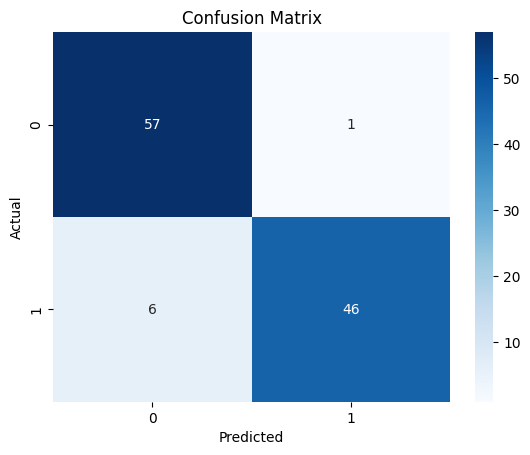

In [14]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test_class, y_pred_class)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

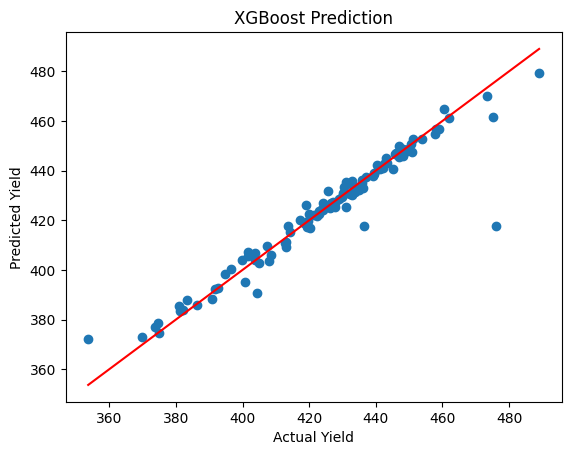

In [15]:
plt.scatter(y_test, y_pred)

plt.xlabel("Actual Yield")
plt.ylabel("Predicted Yield")
plt.title("XGBoost Prediction")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red'
)

plt.show()